# Deteção de Texto IA vs Humano — Modelos PyTorch

**Classes:** `Human · Google · Meta · OpenAI · Anthropic`

Modelos disponíveis (descomenta o que quiseres correr na última célula):

| Modelo | Representação | Função |
|---|---|---|
| Regressão Logística | One-Hot / TF-IDF | `test_logreg()` |
| FFNN | One-Hot / TF-IDF | `test_ffnn()` |
| Embedding + Mean Pooling | Inteiros | `test_embed()` |
| RNN | Inteiros | `test_rnn()` |
| LSTM | Inteiros | `test_lstm()` |
| GRU | Inteiros | `test_gru()` |

## 1. Imports

In [13]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Configuração

In [14]:
TRAIN_PATH  = "data/train.csv"
TEST_PATH   = "data/test.csv"
EXTRA_TEST_PATH = "data/subm2_test.csv"
TEXT_COL    = "Text"
LABEL_COL   = "Label"

LABELS      = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
LABEL2IDX   = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL   = {i: l for l, i in LABEL2IDX.items()}
NUM_CLASSES = len(LABELS)

VAL_SPLIT   = 0.2    # % de train.csv para validação
SEED        = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps"  if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cpu


## 3. Pré-processamento de Texto

In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    most_common = counter.most_common(max_words)
    return {word: i for i, (word, _) in enumerate(most_common)}

def vectorize_text(text, word_index, max_words):
    """One-hot: presença/ausência de cada palavra."""
    vector = torch.zeros(max_words)
    for word in set(text.split()):
        if word in word_index:
            vector[word_index[word]] = 1
    return vector

def encode(text, word_index, max_len=200):
    """Integer encoding com truncagem e padding."""
    tokens = text.split()   # texto já limpo
    seq = [word_index.get(w, 1) for w in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return torch.tensor(seq, dtype=torch.long)

## 4. Carregamento dos Dados

In [16]:
def load_csv(path):
    df = pd.read_csv(path, sep=";")
    texts  = [clean_text(t) for t in df[TEXT_COL].tolist()]
    labels = [LABEL2IDX[l] for l in df[LABEL_COL].tolist()]
    return texts, labels

# Carregar
all_train_texts, all_train_labels = load_csv(TRAIN_PATH)
test_texts,      test_labels      = load_csv(TEST_PATH)

# Dividir treino / validação
train_texts, val_texts, train_labels, val_labels = train_test_split(
    all_train_texts, all_train_labels,
    test_size=VAL_SPLIT, random_state=SEED, stratify=all_train_labels
)

print(f"Treino    : {len(train_texts)}")
print(f"Validação : {len(val_texts)}")
print(f"Teste     : {len(test_texts)}")

# Extra test (subm2)
extra_test_texts, extra_test_labels = load_csv(EXTRA_TEST_PATH)
print(f"Extra Test : {len(extra_test_texts)}")

Treino    : 21200
Validação : 5300
Teste     : 314
Extra Test : 100


## 5. Dataset Classes

In [17]:
class OneHotDataset(Dataset):
    """Representação one-hot (para regressão logística e FFNN)."""
    def __init__(self, texts, labels, word_index, max_words):
        self.texts      = texts
        self.labels     = labels
        self.word_index = word_index
        self.max_words  = max_words

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        return (vectorize_text(self.texts[idx], self.word_index, self.max_words),
                torch.tensor(self.labels[idx], dtype=torch.long))


class TfidfDataset(Dataset):
    """Representação TF-IDF (para regressão logística e FFNN)."""
    def __init__(self, X, labels):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class EmbedDataset(Dataset):
    """Integer encoding (para Embedding, RNN, LSTM, GRU)."""
    def __init__(self, texts, labels, word_index, max_len=200):
        self.texts      = texts
        self.labels     = labels
        self.word_index = word_index
        self.max_len    = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        return (encode(self.texts[idx], self.word_index, self.max_len),
                torch.tensor(self.labels[idx], dtype=torch.long))

## 6. Funções de Carregamento de DataLoaders

In [18]:
def make_onehot_loaders(max_words=10000, batch_size=256):
    word_index = build_vocab(train_texts, max_words)
    tr = DataLoader(OneHotDataset(train_texts, train_labels, word_index, max_words),
                    batch_size=batch_size, shuffle=True)
    vl = DataLoader(OneHotDataset(val_texts,   val_labels,   word_index, max_words),
                    batch_size=batch_size)
    te = DataLoader(OneHotDataset(test_texts,  test_labels,  word_index, max_words),
                    batch_size=batch_size)
    ex = DataLoader(OneHotDataset(extra_test_texts, extra_test_labels, word_index, max_words),  # ← novo
                    batch_size=batch_size)
    return tr, vl, te, ex, max_words  # ← ex adicionado


def make_tfidf_loaders(max_words=20000, batch_size=256):
    vect = TfidfVectorizer(max_features=max_words, ngram_range=(1,2),
                           stop_words="english", min_df=5)
    X_tr = vect.fit_transform(train_texts).toarray()
    X_vl = vect.transform(val_texts).toarray()
    X_te = vect.transform(test_texts).toarray()
    X_ex = vect.transform(extra_test_texts).toarray()  # ← novo
    input_dim = X_tr.shape[1]
    tr = DataLoader(TfidfDataset(X_tr, train_labels), batch_size=batch_size, shuffle=True)
    vl = DataLoader(TfidfDataset(X_vl, val_labels),   batch_size=batch_size)
    te = DataLoader(TfidfDataset(X_te, test_labels),  batch_size=batch_size)
    ex = DataLoader(TfidfDataset(X_ex, extra_test_labels), batch_size=batch_size)  # ← novo
    return tr, vl, te, ex, input_dim  # ← ex adicionado


def make_embed_loaders(max_words=20000, max_len=200, batch_size=256):
    word_index = build_vocab(train_texts, max_words)
    tr = DataLoader(EmbedDataset(train_texts, train_labels, word_index, max_len),
                    batch_size=batch_size, shuffle=True)
    vl = DataLoader(EmbedDataset(val_texts,   val_labels,   word_index, max_len),
                    batch_size=batch_size)
    te = DataLoader(EmbedDataset(test_texts,  test_labels,  word_index, max_len),
                    batch_size=batch_size)
    ex = DataLoader(EmbedDataset(extra_test_texts, extra_test_labels, word_index, max_len),  # ← novo
                    batch_size=batch_size)
    return tr, vl, te, ex, max_words  # ← ex adicionado

## 7. Modelos

In [19]:
# ── Regressão Logística ───────────────────────────────────────────────────────
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=NUM_CLASSES):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    def forward(self, x): return self.linear(x)


# ── FFNN ─────────────────────────────────────────────────────────────────────
class FFNN(nn.Module):
    def __init__(self, input_dim, topology=[256, 128], dropout=0.3, num_classes=NUM_CLASSES):
        super().__init__()
        layers = []
        prev = input_dim
        for h in topology:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0: layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


# ── Embedding + Mean Pooling ──────────────────────────────────────────────────
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        return self.fc(self.embedding(x).mean(dim=1))


# ── RNN ───────────────────────────────────────────────────────────────────────
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        _, hidden = self.rnn(self.embedding(x))
        return self.fc(hidden[-1])


# ── LSTM ──────────────────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.0, bidirectional=False, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, num_classes)

    def forward(self, x):
        _, (hidden, _) = self.lstm(self.embedding(x))
        last = torch.cat((hidden[-2], hidden[-1]), 1) if self.lstm.bidirectional else hidden[-1]
        return self.fc(self.dropout(last))


# ── GRU ───────────────────────────────────────────────────────────────────────
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.0, bidirectional=False, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=bidirectional,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, num_classes)

    def forward(self, x):
        _, hidden = self.gru(self.embedding(x))
        last = torch.cat((hidden[-2], hidden[-1]), 1) if self.gru.bidirectional else hidden[-1]
        return self.fc(self.dropout(last))

## 8. Treino, Avaliação e Visualização

In [20]:
criterion = nn.CrossEntropyLoss()

# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Para o treino quando val_loss não melhora há `patience` épocas.
    Guarda e restaura automaticamente os pesos do melhor modelo.
    """
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = np.inf
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        """Devolve True se deve parar."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)

# patience=None desactiva o early stopping
ES_PATIENCE  = 5
ES_MIN_DELTA = 1e-4

def train_model(model, train_loader, val_loader, epochs=50, lr=0.01,
                patience=ES_PATIENCE, min_delta=ES_MIN_DELTA):
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(DEVICE)
    history    = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    es         = EarlyStopping(patience, min_delta) if patience else None

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()

        tr_loss, tr_acc = evaluate_loader(model, train_loader)
        vl_loss, vl_acc = evaluate_loader(model, val_loader)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        stop_marker = ""
        if es:
            if es.step(vl_loss, model):
                print(f"  Early stopping na época {epoch} (sem melhoria há {patience} épocas).")
                es.restore(model)
                break
            stop_marker = f" [{es.counter}/{patience}]" if es.counter > 0 else " ✓"

        if epoch % 5 == 0:
            print(f"  Época {epoch:02d}/{epochs} | "
                  f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
                  f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}{stop_marker}")
    return history


def evaluate_loader(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            total_loss += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    return total_loss / len(loader), correct / total


def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    for ax, metric, ylabel in zip(axes, ["acc", "loss"], ["Accuracy", "CrossEntropy Loss"]):
        ax.plot(epochs, history[f"train_{metric}"], label="Train")
        ax.plot(epochs, history[f"val_{metric}"],   label="Validation")
        ax.set_title(f"{ylabel} por época")
        ax.set_xlabel("Época"); ax.set_ylabel(ylabel)
        ax.legend()
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def test_report(model, test_loader, title=""):
    """Avaliação final: accuracy, classification report e matriz de confusão."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            preds = model(x.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"\n{'='*50}")
    print(f"{title} — Test Accuracy: {acc:.4f}")
    print('='*50)
    print(classification_report(all_labels, all_preds, target_names=LABELS, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Blues")
    plt.title(f"{title} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return acc

## 9. Funções de Teste por Modelo

In [21]:
import os

EXPORT_DIR = "exported_models"

def _save_model(checkpoint, filename):
    os.makedirs(EXPORT_DIR, exist_ok=True)
    path = os.path.join(EXPORT_DIR, filename)
    torch.save(checkpoint, path)
    size_mb = os.path.getsize(path) / 1e6
    print(f"  ✅ Modelo guardado: {path}  ({size_mb:.1f} MB)")


def test_logreg(use_tfidf=True, max_words=10000, epochs=30, lr=0.001, weight_decay=1e-3, save=False):
    """Regressão Logística com One-Hot ou TF-IDF."""
    name = "LogReg TF-IDF" if use_tfidf else "LogReg One-Hot"
    print(f"\n▶ {name}")
    if use_tfidf:
        tr, vl, te, ex, input_dim = make_tfidf_loaders(max_words)  # ← ex
    else:
        tr, vl, te, ex, input_dim = make_onehot_loaders(max_words)
    model = SimpleClassifier(input_dim)
    # weight_decay como regularização L2 contra overfitting
    optimizer_fn = lambda p: torch.optim.Adam(p, lr=lr, weight_decay=weight_decay)
    # substitui o optimizer interno temporariamente
    model.to(DEVICE)
    opt = optimizer_fn(model.parameters())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    es = EarlyStopping(ES_PATIENCE, ES_MIN_DELTA)
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); criterion(model(x), y).backward(); opt.step()
        tr_l, tr_a = evaluate_loader(model, tr)
        vl_l, vl_a = evaluate_loader(model, vl)
        for k, v in zip(["train_loss","val_loss","train_acc","val_acc"],[tr_l,vl_l,tr_a,vl_a]):
            history[k].append(v)
        if es.step(vl_l, model):
            print(f"  Early stopping na época {epoch} (sem melhoria há {ES_PATIENCE} épocas).")
            es.restore(model)
            break
        if epoch % 5 == 0:
            print(f"  Época {epoch:02d}/{epochs} | Train Loss {tr_l:.4f} Acc {tr_a:.4f} | Val Loss {vl_l:.4f} Acc {vl_a:.4f}")
    plot_history(history, name)
    test_report(model, te, name)
    test_report(model, ex, name + " · Extra Test")             # ← linha nova


def test_ffnn(use_tfidf=True, max_words=20000, topology=[256, 128], dropout=0.4, epochs=20, save=False):
    """Feed-Forward Neural Network."""
    name = f"FFNN {topology} TF-IDF" if use_tfidf else f"FFNN {topology} One-Hot"
    print(f"\n▶ {name}")
    if use_tfidf:
        tr, vl, te, ex, input_dim = make_tfidf_loaders(max_words)  # ← ex
        word_index = None
    else:
        tr, vl, te, ex, input_dim = make_onehot_loaders(max_words)
        word_index = build_vocab(train_texts, max_words)
    model = FFNN(input_dim, topology=topology, dropout=dropout)
    history = train_model(model, tr, vl, epochs=epochs)
    plot_history(history, name)
    test_report(model, te, name)
    test_report(model, ex, name + " · Extra Test")             # ← linha nova
    if save:
        _save_model({
            "model_class" : "FFNN",
            "model_state" : model.cpu().state_dict(),
            "config"      : {"input_dim": input_dim, "topology": topology,
                              "dropout": dropout, "num_classes": NUM_CLASSES},
            "representation": "tfidf" if use_tfidf else "one_hot",
            "word_index"  : word_index,
            "max_words"   : max_words,
            "labels"      : LABELS, "label2idx": LABEL2IDX, "idx2label": IDX2LABEL,
        }, "best_ffnn.pt")


def test_embed(max_words=20000, max_len=150, embed_dim=128, epochs=20, save=False):
    """Embedding + Mean Pooling."""
    name = "Embedding + Mean Pooling"
    print(f"\n▶ {name}")
    word_index = build_vocab(train_texts, max_words)
    tr, vl, te, ex, vocab_size = make_embed_loaders(max_words, max_len)
    model = EmbeddingClassifier(vocab_size, embed_dim)
    history = train_model(model, tr, vl, epochs=epochs)
    plot_history(history, name)
    test_report(model, te, name)
    test_report(model, ex, name + " · Extra Test")             # ← linha nova
    if save:
        _save_model({
            "model_class" : "EmbeddingClassifier",
            "model_state" : model.cpu().state_dict(),
            "config"      : {"vocab_size": vocab_size, "embed_dim": embed_dim,
                              "num_classes": NUM_CLASSES},
            "representation": "integer",
            "word_index"  : word_index,
            "max_words"   : max_words,
            "max_len"     : max_len,
            "labels"      : LABELS, "label2idx": LABEL2IDX, "idx2label": IDX2LABEL,
        }, "best_embed.pt")


def test_rnn(max_words=20000, max_len=150, embed_dim=128, hidden_dim=128, num_layers=1, epochs=20):
    """RNN simples."""
    name = f"RNN (hidden={hidden_dim}, layers={num_layers})"
    print(f"\n▶ {name}")
    tr, vl, te, ex, vocab_size = make_embed_loaders(max_words, max_len)
    model = RNNClassifier(vocab_size, embed_dim, hidden_dim, num_layers)
    history = train_model(model, tr, vl, epochs=epochs)
    plot_history(history, name)
    test_report(model, te, name)
    test_report(model, ex, name + " · Extra Test")             # ← linha nova


def test_lstm(max_words=20000, max_len=150, embed_dim=128, hidden_dim=128,
              num_layers=2, dropout=0.5, bidirectional=True, epochs=20):
    """LSTM (por defeito: bidirecional, 2 camadas)."""
    name = f"LSTM (bi={bidirectional}, layers={num_layers}, drop={dropout})"
    print(f"\n▶ {name}")
    tr, vl, te, ex, vocab_size = make_embed_loaders(max_words, max_len)
    model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_layers, dropout, bidirectional)
    history = train_model(model, tr, vl, epochs=epochs)
    plot_history(history, name)
    test_report(model, te, name)
    test_report(model, ex, name + " · Extra Test")             # ← linha nova


def test_gru(max_words=20000, max_len=150, embed_dim=128, hidden_dim=128,
             num_layers=1, dropout=0.3, bidirectional=True, epochs=20):
    """GRU (por defeito: bidirecional, 1 camada)."""
    name = f"GRU (bi={bidirectional}, layers={num_layers}, drop={dropout})"
    print(f"\n▶ {name}")
    tr, vl, te, ex, vocab_size = make_embed_loaders(max_words, max_len)
    model = GRUClassifier(vocab_size, embed_dim, hidden_dim, num_layers, dropout, bidirectional)
    history = train_model(model, tr, vl, epochs=epochs)
    plot_history(history, name)
    test_report(model, te, name)
    test_report(model, ex, name + " · Extra Test")             # ← linha nova

## 10. Correr Modelos

Descomenta o(s) modelo(s) que quiseres testar.  
Todos os parâmetros têm valores por defeito — podes sobrepô-los directamente na chamada.


▶ Embedding + Mean Pooling
  Época 05/20 | Train Loss 0.3021 Acc 0.9163 | Val Loss 0.7786 Acc 0.7236 [1/5]
  Early stopping na época 9 (sem melhoria há 5 épocas).


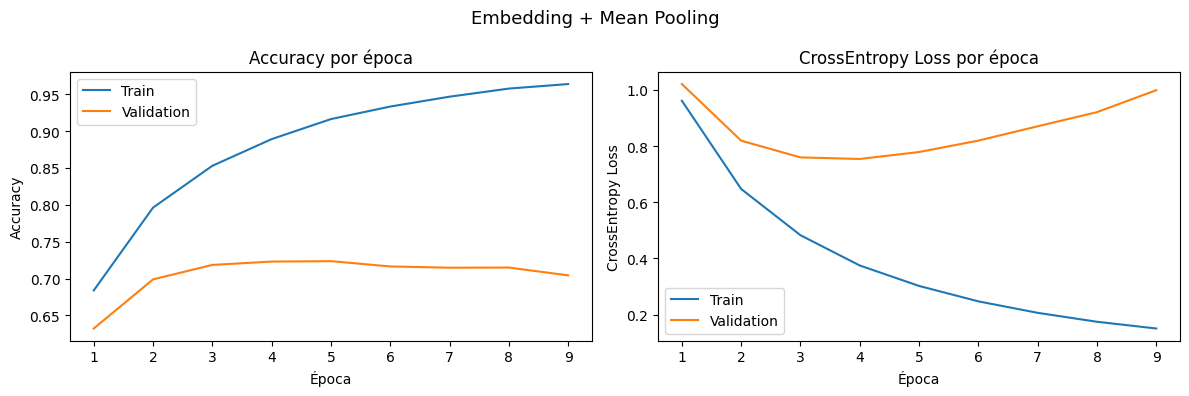


Embedding + Mean Pooling — Test Accuracy: 0.5605
              precision    recall  f1-score   support

       Human       0.81      0.81      0.81       116
      Google       0.60      0.47      0.53        51
        Meta       0.50      0.53      0.51        51
      OpenAI       0.30      0.70      0.42        44
   Anthropic       0.00      0.00      0.00        52

    accuracy                           0.56       314
   macro avg       0.44      0.50      0.45       314
weighted avg       0.52      0.56      0.53       314



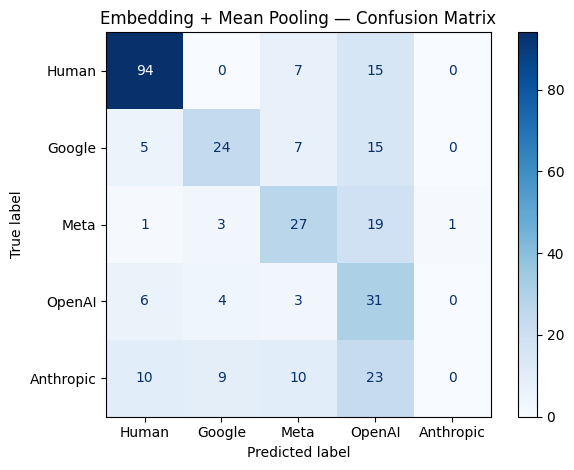


Embedding + Mean Pooling · Extra Test — Test Accuracy: 0.5800
              precision    recall  f1-score   support

       Human       0.78      0.82      0.80        34
      Google       0.64      0.39      0.48        18
        Meta       0.55      0.69      0.61        16
      OpenAI       0.36      0.75      0.49        16
   Anthropic       0.00      0.00      0.00        16

    accuracy                           0.58       100
   macro avg       0.47      0.53      0.48       100
weighted avg       0.53      0.58      0.54       100



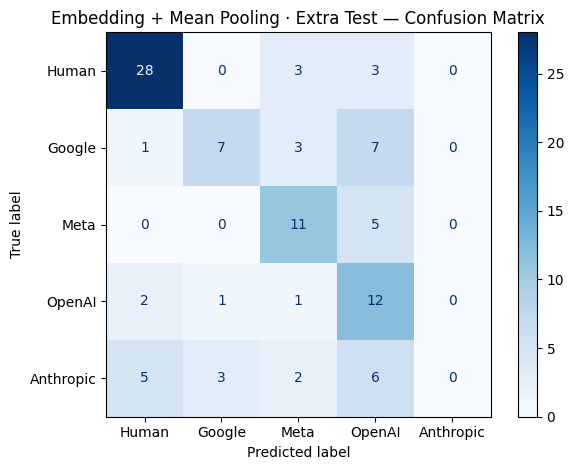

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Regressão Logística ───────────────────────────────────────────
#test_logreg()                                  # TF-IDF (default) 0.44 test, 0.44 subm2
#test_logreg(use_tfidf=False)                   # One-Hot 0.544, 0.61 subm2
#test_logreg(weight_decay=1e-2, epochs=20)      # mais regularização 0.41 teest, 0.45

# ── FFNN ─────────────────────────────────────────────────────────
#test_ffnn()                                    # TF-IDF (default) 0.48 teest, 0.49 subm2
#test_ffnn(topology=[512, 256, 128], dropout=0.5, use_tfidf=False) # 0.54 test, 0.55 subm2
# MODELO SUBM3 A
test_ffnn(topology=[512, 256, 128], use_tfidf=False, save=True) # 0.554 test, 0.62 subm2
#test_ffnn(use_tfidf=False)                     # One-Hot 0.554 test, 0.60 subm2

# ── Embedding ────────────────────────────────────────────────────
#test_embed(save=True) # 0.566 test, 0.58 subm2

# MODELO SUBM3 B
test_embed(embed_dim=256, max_len=300) # 0.56 test, 0.58 subm2

# ── RNN ──────────────────────────────────────────────────────────
#test_rnn() # 0.17 test, 0.18 subm2
#test_rnn(num_layers=2, hidden_dim=256) # test 0.14, subm2 0.11

# ── LSTM ─────────────────────────────────────────────────────────
#test_lstm() # 0.42 test, 0.40 subm2
#test_lstm(bidirectional=False, num_layers=1, dropout=0.3) # 0.426 teste, 0.39 subm2

# ── GRU ──────────────────────────────────────────────────────────
#test_gru() # 0.42 teste, subm2 0.40
#test_gru(num_layers=2, dropout=0.5) # teste 0.474, subm2 0.47
#test_gru(num_layers=3, dropout=0.5) # teste 0.439, subm2 0.45